In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

# Breast Cancer Dataset ( from sklearn )

In [36]:
breast_cancer_dataset = pd.read_csv("/content/drive/MyDrive/DM/datasets/wdbc.csv",index_col='ID')
breast_cancer_dataset.head()

,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractcal_dimension3
ID,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Information about the features and the target class

In [37]:
breast_cancer_dataset.info()


<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 842302 to 92751
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Diagnosis            569 non-null    object 
 1   radius1              569 non-null    float64
 2   texture1             569 non-null    float64
 3   perimeter1           569 non-null    float64
 4   area1                569 non-null    float64
 5   smoothness1          569 non-null    float64
 6   compactness1         569 non-null    float64
 7   concavity1           569 non-null    float64
 8   concave_points1      569 non-null    float64
 9   symmetry1            569 non-null    float64
 10  fractal_dimensions1  569 non-null    float64
 11  radius2              569 non-null    float64
 12  texture2             569 non-null    float64
 13  perimeter2           569 non-null    float64
 14  area2                569 non-null    float64
 15  smoothness2          569 non-null    f

# Separating the features and the target class

In [38]:
X_cols = breast_cancer_dataset.columns[breast_cancer_dataset.columns != 'Diagnosis']
X = breast_cancer_dataset.loc[:,X_cols].copy()

X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimensions1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractcal_dimension3
ID,,,,,,,,,,,,,,,,,,,,,
842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [39]:
y_col = 'Diagnosis'
y = breast_cancer_dataset.loc[:,y_col].copy()

y.head()

,Diagnosis
ID,
842302,M
842517,M
84300903,M
84348301,M
84358402,M


# Preprocessing

## Distribution of the target class

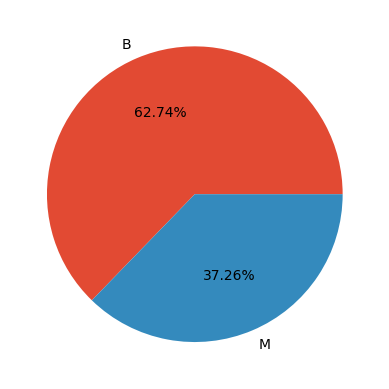

In [40]:
plt.style.use("ggplot")
plt.pie(y.value_counts(normalize=True),autopct="%.2f%%",labels=y.value_counts().index)
plt.show()

## Encoding the target class

In [41]:
encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)
y_index = y.index
y = pd.Series(y_enc)
y.index = y_index

y.head()

,0
ID,
842302,1
842517,1
84300903,1
84348301,1
84358402,1


## Splitting the dataset into training and test datasets
 - training dataset size : 20%
 - test dataset size : 80%


In [43]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=0)
x_feat_names = x_train.columns



## Applying Synthetic Minority Oversampling Technique (SMOTE) to balance the target class

In [44]:
sampler = SMOTE()
x_train,y_train = sampler.fit_resample(x_train,y_train)

x_train = pd.DataFrame(x_train)
x_train.columns = x_feat_names

y_train = pd.Series(y_train)

# Ada-Boost classifier
 - with decision tree as base classifier

In [46]:
ada_boost = AdaBoostClassifier(n_estimators=100,random_state=0)
ada_boost_classifier = ada_boost.fit(x_train,y_train)
y_pred =  ada_boost_classifier.predict(x_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0])

## Confusion Matrix for AdaBoost

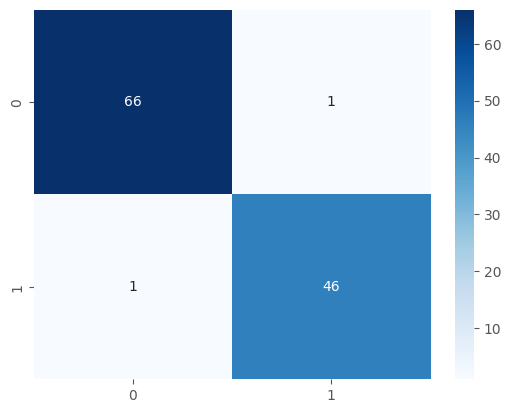

In [47]:
conf_matrix = confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap=plt.cm.Blues)
plt.show()

## Reprot for AdaBoost

In [48]:
ada_boost_report = classification_report(y_test,y_pred,output_dict=True)
ada_boost_report = pd.DataFrame(ada_boost_report)
ada_boost_report

,0,1,accuracy,macro avg,weighted avg
precision,0.985075,0.978723,0.982456,0.981899,0.982456
recall,0.985075,0.978723,0.982456,0.981899,0.982456
f1-score,0.985075,0.978723,0.982456,0.981899,0.982456
support,67.000000,47.000000,0.982456,114.000000,114.000000


# Decision Tree Classifier

In [49]:
decision_tree = DecisionTreeClassifier()
model = decision_tree.fit(x_train,y_train)
x_test = pd.DataFrame(x_test)
x_test.columns = x_feat_names
y_pred = decision_tree.predict(x_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 1])

## Confusion Matrix for decision tree

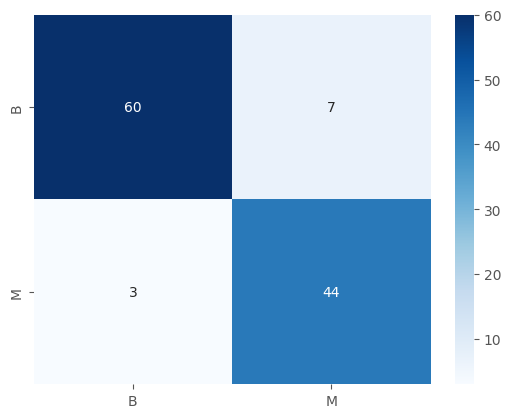

In [50]:
conf_matrix = confusion_matrix(y_pred=y_pred,y_true=y_test)
sns.heatmap(conf_matrix,annot=True,cmap=plt.cm.Blues,xticklabels=['B','M'],yticklabels=['B','M'])
plt.show()

## Report  for decision tree

In [52]:
dt_report = classification_report(y_pred=y_pred,y_true=y_test,output_dict=True)
dt_report = pd.DataFrame(dt_report)
dt_report

,0,1,accuracy,macro avg,weighted avg
precision,0.952381,0.862745,0.912281,0.907563,0.915426
recall,0.895522,0.936170,0.912281,0.915846,0.912281
f1-score,0.923077,0.897959,0.912281,0.910518,0.912721
support,67.000000,47.000000,0.912281,114.000000,114.000000


# Final Report Comparing Decision Tree & AdaBoost

In [56]:
final_report = {
    'Decision Tree':{
        'precision' : dt_report.loc['precision','weighted avg'],
        'recall' : dt_report.loc['recall','weighted avg'],
        "f1-score":dt_report.loc['f1-score','weighted avg'],
        "accuracy" : dt_report.loc['precision','accuracy']
                     },
    'Ada Boost': {
        'precision' : ada_boost_report.loc['precision','weighted avg'],
        'recall' : ada_boost_report.loc['recall','weighted avg'],
        "f1-score":ada_boost_report.loc['f1-score','weighted avg'],
        "accuracy" : ada_boost_report.loc['precision','accuracy']
    }
}
final_report = pd.DataFrame(final_report)
final_report

,Decision Tree,Ada Boost
precision,0.915426,0.982456
recall,0.912281,0.982456
f1-score,0.912721,0.982456
accuracy,0.912281,0.982456
